In [7]:
from langgraph.graph import StateGraph, START, MessagesState,END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [3]:
load_dotenv()

True

In [4]:
model = ChatOllama(base_url="http://206.1.53.104:11434/", model="qwen2.5-coder:7b")

In [5]:
MAX_TOKENS = 150

In [6]:
def call_model(state: MessagesState):
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )
    print("Current Token Count ->", count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)
    
    return {"messages":[response]}

In [8]:
graph=StateGraph(MessagesState)

graph.add_node("call_model", call_model)
graph.add_edge(START,"call_model")
graph.add_edge("call_model",END)




In [9]:
checkpointer=InMemorySaver()
builder=graph.compile(checkpointer=checkpointer)

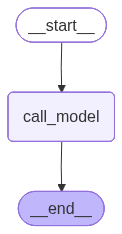

In [10]:
builder

In [17]:
config = {"configurable": {"thread_id": "chat-1"}}

result = builder.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 75
What is my name?
I'm sorry, but I don't have access to personal information such as your name unless it has been shared with me in the course of our conversation. If you'd like to tell me your name, I would be happy to know!
Hi, my name is Nitish.


"Hello Nitish! It's nice to meet you. How can I assist you today?"

In [26]:
result = builder.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 114
What is my name?
Your name is Nitish. Is there anything else I can help you with today?
What is my name?
Based on the previous interactions, your name is Nitish. If you have any other questions or need assistance, feel free to let me know!
What is my name?
Your name is Nitish. How can I assist you today?
I am learning LangGraph.


"That's great! LangGraph is a powerful tool for handling and analyzing large-scale graph data. It allows you to perform complex queries, analysis, and machine learning tasks on graph structures.\n\nHere are a few key features of LangGraph that might be useful as you learn:\n\n1. **Graph Representation**: LangGraph allows you to represent relationships between entities in the form of graphs, where nodes (entities) and edges (relationships) make up the graph structure.\n2. **Querying**: It provides a way to query the graph using SQL-like syntax, making it easier to extract insights from your data.\n3. **Analysis**: LangGraph offers various algorithms for analyzing graph properties such as centrality measures, community detection, shortest paths, and more.\n4. **Machine Learning**: You can perform machine learning tasks directly on the graph data, leveraging the relationships between nodes.\n\nIf you have any specific questions or need help with a particular aspect of using LangGraph, fee

In [27]:
result = builder.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is the cognitive process that temporarily holds information for processing in working memory. It plays a crucial role in our ability to remember and manipulate information over brief intervals, typically lasting from seconds to minutes. Here are some key points about short-term memory:\n\n1. Capacity: STM has a limited capacity, often estimated to be around 7 items plus or minus 2.\n\n2. Duration: Information is retained for an average of 15-30 seconds without rehearsal (repetition).\n\n3. Content: It holds information in various forms such as words, images, sounds, and sensations.\n\n4. Encoding: New information enters STM through sensory receptors and is encoded into a form that can be easily processed and manipulated.\n\n5. Maintenance: Information remains in STM through a process called maintenance rehearsal, where the individual repeatedly thinks about or focuses on the information to keep it active.\n\n6. Storage limitations: STM has strict storage limita

In [33]:
result = builder.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 121
What is my name?
Your name is Qwen.
What is my name?
I'm sorry, but I don't have access to personal information such as your name unless it was shared with me during our conversation. How can I assist you today?
What is my name?
I apologize for the confusion earlier. Based on our interaction, your name is Qwen. How can I assist you further?
What is my name?


'Your name is Qwen.'